In [1]:
# from utils.plotting.wasserstein_distance_clustering import pairwise_wasserstein

In [2]:
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from einops import einsum

from pep_compass.models.encoder_decoder.hydramp_encoder_decoder import (
    HydrAMPEncoderDecoder,
)
from pep_compass.local_enumeration.mutation.mutation_enumerator import (
    MutationEnumerationInTangentSpace,
)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
hydramp = HydrAMPEncoderDecoder(
    jacobian_mode="approx",
    jacobian_eps=0.05,
    field_eps=0.05,
    device=device,
)
mutang = MutationEnumerationInTangentSpace(
    max_len=25,
    direction_significance_threshold=0.001,
    min_number_of_directions=5,
    token_threshold=0.1,
)

In [5]:
diff_values_path = Path(
    "/home/prz/bioml/pep-compass/results/mutation_analysis/hydramp_x_ampsphere/direction_threshold=0.001_token_threshold=0.1_jacobian_mode=approx_jacobian_eps=0.05/ngram1/diff_values.csv"
)
diff_df = pd.read_csv(diff_values_path, chunksize=100, iterator=True, low_memory=True)

In [6]:
# seqs = diff_df["parent"].unique().tolist()

In [7]:
from functools import partial
from pep_compass.models.encoder_decoder.utils import decoder_jacobian_approx

In [8]:
dec_jac_wrpd = partial(
    decoder_jacobian_approx,
    decoder_forward=hydramp.decoder_forward,
    jacobian_eps=0.05,
)

In [9]:
from tqdm import tqdm

In [10]:
agrammtx_lst = []
num_batches = 10  # Control the number of batches to process

for i, chunk in enumerate(tqdm(diff_df, total=num_batches)):
    if i >= num_batches:
        break
    seqs = chunk["parent"].tolist()
    seq_tensor = hydramp.encode_peptides(seqs)
    jac = dec_jac_wrpd(x=seq_tensor)  # shape: (B, S*V, Z)
    U, S, Vh = torch.linalg.svd(jac, full_matrices=False)
    agrammtx = einsum(jac, jac, "b a1 d, b a2 d -> b a1 a2")
    agrammtx_lst.append(agrammtx)  # [mask])

# Concatenate all collected gram matrices
agrammtx_all = torch.cat(agrammtx_lst, dim=0)

100%|██████████| 10/10 [00:39<00:00,  3.92s/it]


In [11]:
agrammtx_all.shape

torch.Size([1000, 525, 525])

In [ ]:
from utils.plotting.wasserstein_distance import pairwise_wasserstein
import numpy as np

# Assuming you have a tensor of shape [1000, 525, 525]
# tensor = torch.stack(agrammtx_lst)  # or however you created it

# Convert to numpy and flatten each 525x525 matrix into a 1D distribution
tensor_np = agrammtx_all[:5].cpu().numpy()  # Shape: (1000, 525, 525)

# Flatten each matrix into a 1D array of values
values_list = [tensor_np[i].flatten() for i in range(tensor_np.shape[0])]

# Compute pairwise Wasserstein distances
# This will return a (1000, 1000) distance matrix
distance_matrix = pairwise_wasserstein(values_list)

/home/prz/bioml/pep-compass/.venv/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/home/prz/bioml/pep-compass/analysis/utils/plotting/wasserstein_distance.py:84: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  u_vals = values_list[i]


In [4]:
((525 * 525 - 525) // 2) ** 2

18920002500

In [ ]:
distance_matrix

In [ ]:
# TODO @pszmk : collect values for multiple samples

In [ ]:
# TODO @pszmk : plot just the mutation matrix for a given dimension in the latent from svd -> look what is shown - what are the correlations?

seq_tensor = hydramp.encode_peptides([seq])

jac = dec_jac_wrpd(x=seq_tensor)  # shape: (B, S*V, Z)
# --- SVD ---
U, S, Vh = torch.linalg.svd(jac, full_matrices=False)

In [ ]:
seq = "FLGLLFHGVHHVGKWIHGLIHGHH"
mutatnt = "FLGLLFHGVHHVGKWIHGNIHGHH"
z = hydramp.encode_peptides([seq])
z.shape
jac = hydramp.decoder_jacobian(z)

---

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def plot_heatmap(
    matrix,
    title="Heatmap",
    xlabel="X",
    ylabel="Y",
    cmap="viridis",
    center=0,
    figsize=(10, 8),
    xticklabels=None,
    yticklabels=None,
    original_sequence=None,
    alphabet=None,
):
    """
    Plot a heatmap with optional tick labels.

    Args:
        matrix: 2D array to plot
        title: plot title
        xlabel: x-axis label
        ylabel: y-axis label
        cmap: colormap
        center: center value for colormap
        figsize: figure size tuple
        xticklabels: list of x-axis tick labels (or None for default)
        yticklabels: list of y-axis tick labels (or None for default)
        original_sequence: optional sequence string to mark original AAs with black squares
        alphabet: optional list of amino acids matching xticklabels order
    """
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        matrix,
        cmap=cmap,
        center=center,
        xticklabels=xticklabels if xticklabels is not None else "auto",
        yticklabels=yticklabels if yticklabels is not None else "auto",
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Mark original amino acids with black squares
    if original_sequence is not None and alphabet is not None:
        for pos, aa in enumerate(original_sequence):
            try:
                # Find the column index for this amino acid in the alphabet
                aa_col = alphabet.index(aa)
                # Draw a black filled square at this position
                # In heatmap coordinates: (x, y) where x is column, y is row
                # Each cell is 1x1, centered at (col + 0.5, row + 0.5)
                rect = patches.Rectangle(
                    (aa_col, pos),  # bottom-left corner
                    1,  # width
                    1,  # height
                    fill=True,
                    facecolor="black",
                    edgecolor="black",
                    linewidth=0,
                    transform=ax.transData,
                )
                ax.add_patch(rect)
            except ValueError:
                # Amino acid not found in alphabet, skip
                pass

    plt.show()

In [11]:
pbmgrammtx = einsum(jac, jac, "b a d, b a e -> b d e")
# Normalize jacobian vectors in the ambient space
jac_norms = torch.linalg.norm(jac, dim=1, keepdim=True)  # shape: (b, 1, d)
jac_normalized = jac / jac_norms  # shape: (b, a, d)
pbmgrammtxnrm = einsum(jac_normalized, jac_normalized, "b a d, b a e -> b d e")

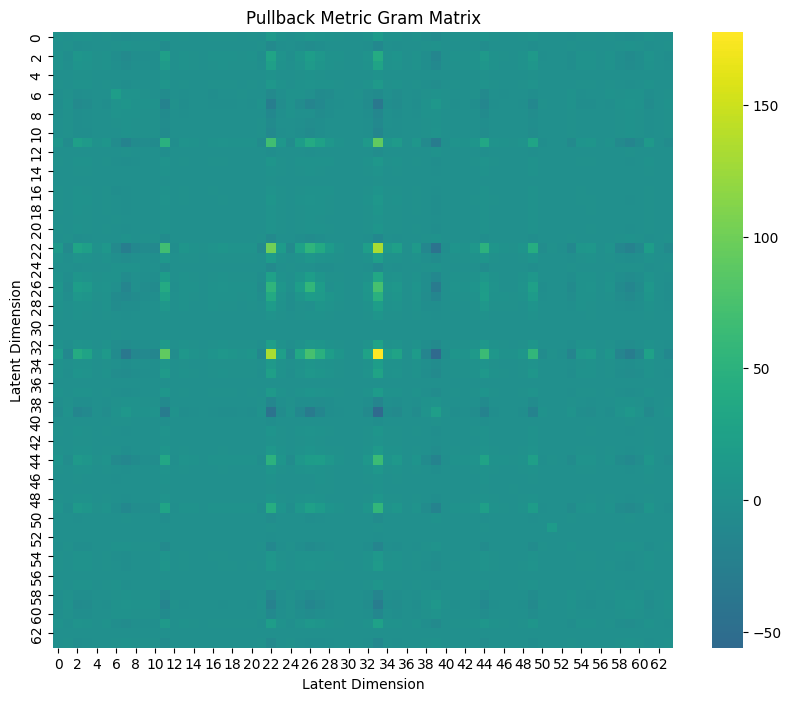

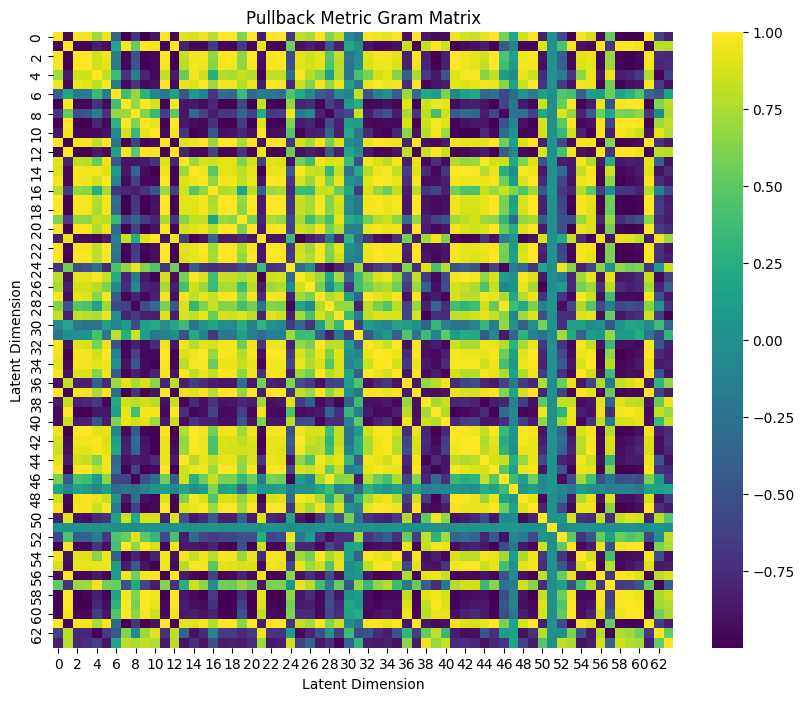

In [12]:
plot_heatmap(
    matrix=pbmgrammtx[0].cpu().numpy(),
    title="Pullback Metric Gram Matrix",
    xlabel="Latent Dimension",
    ylabel="Latent Dimension",
)

plot_heatmap(
    matrix=pbmgrammtxnrm[0].cpu().numpy(),
    title="Pullback Metric Gram Matrix",
    xlabel="Latent Dimension",
    ylabel="Latent Dimension",
)

In [13]:
agrammtx = einsum(jac, jac, "b a1 d, b a2 d -> b a1 a2")
# Normalize jacobian vectors in the ambient space
jac_norms_l = torch.linalg.norm(jac, dim=2, keepdim=True)  # shape: (b, a, 1)
jac_normalized_l = jac / jac_norms_l  # shape: (b, a, d)
agrammtxnrm_l = einsum(jac_normalized_l, jac_normalized_l, "b a1 d, b a2 d -> b a1 a2")

In [14]:
torch.isnan(agrammtx).sum()

tensor(0)

In [15]:
agrammtxnrm_l

tensor([[[ 1.0000,  0.9236, -0.7571,  ...,  0.0560,  0.0440, -0.0423],
         [ 0.9236,  1.0000, -0.8618,  ...,  0.0479,  0.0393, -0.0132],
         [-0.7571, -0.8618,  1.0000,  ..., -0.0515, -0.0389, -0.0365],
         ...,
         [ 0.0560,  0.0479, -0.0515,  ...,  1.0000,  0.9880, -0.4001],
         [ 0.0440,  0.0393, -0.0389,  ...,  0.9880,  1.0000, -0.4287],
         [-0.0423, -0.0132, -0.0365,  ..., -0.4001, -0.4287,  1.0000]]])

In [16]:
agrammtxnrm_l_np = agrammtxnrm_l[0].cpu().numpy()
agrammtxnrm_l_np = np.nan_to_num(agrammtxnrm_l_np, nan=0.0)
np.isnan(agrammtxnrm_l_np).sum(), 500**2

(np.int64(0), 250000)

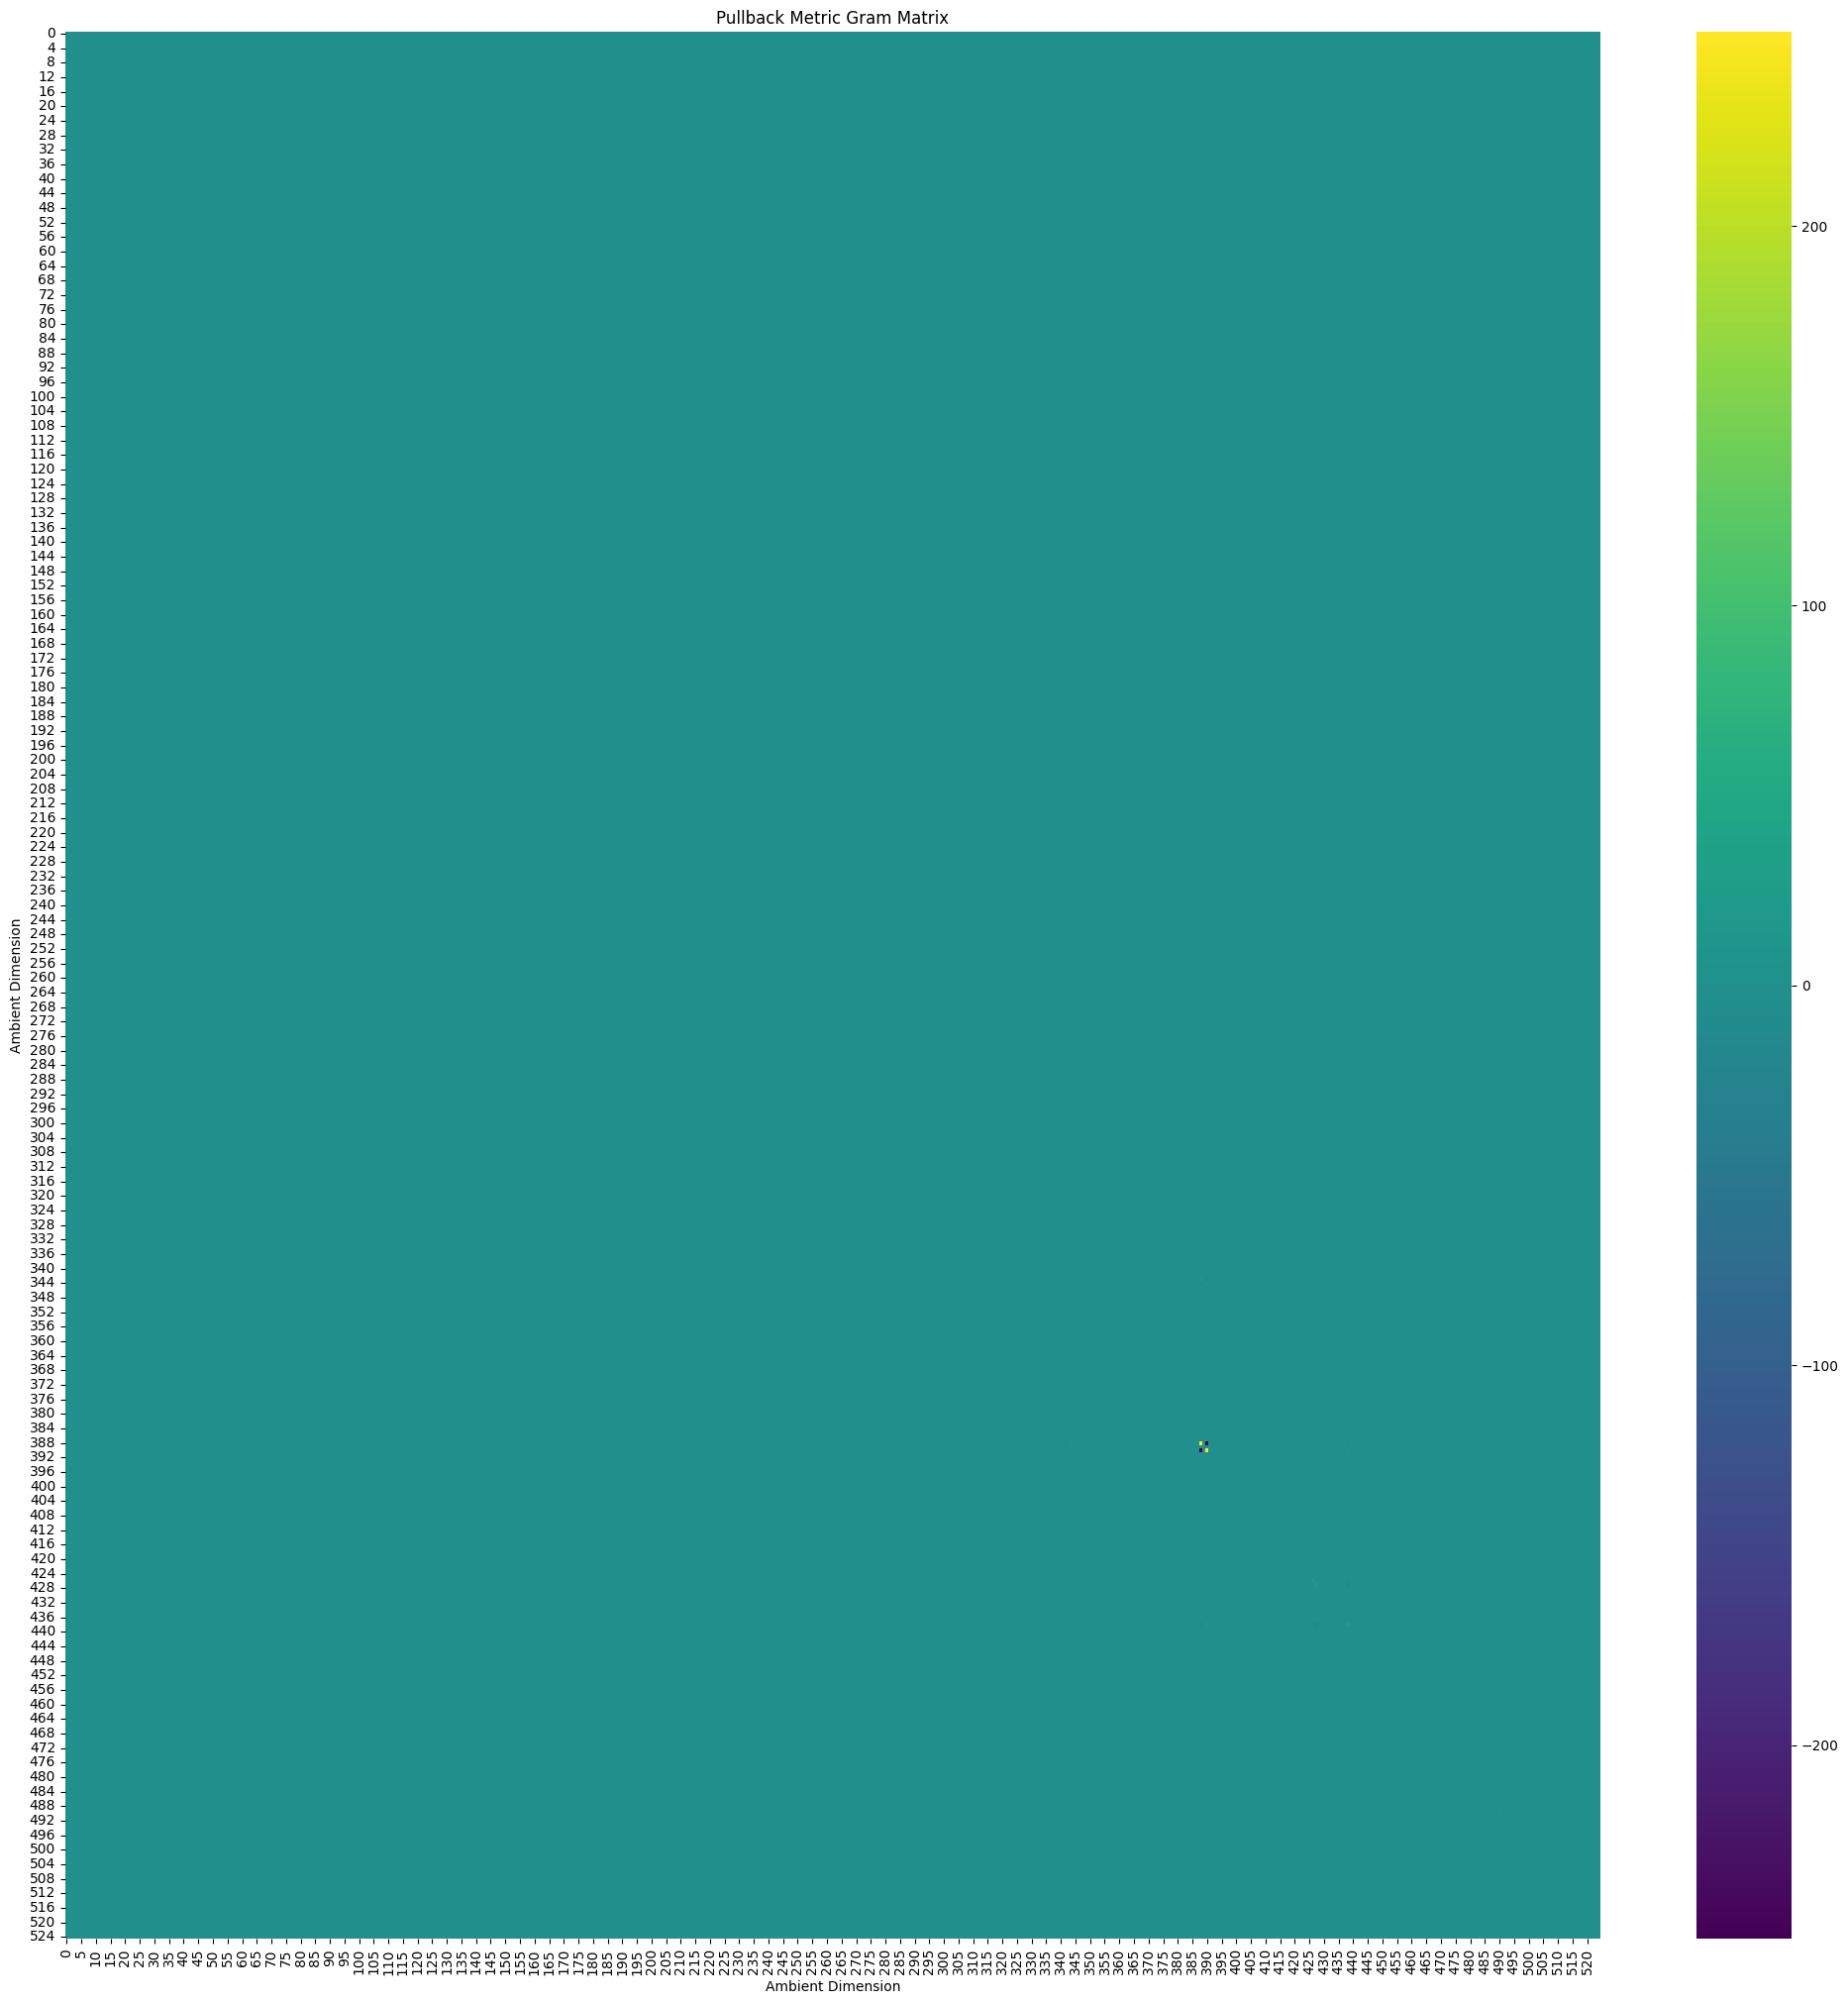

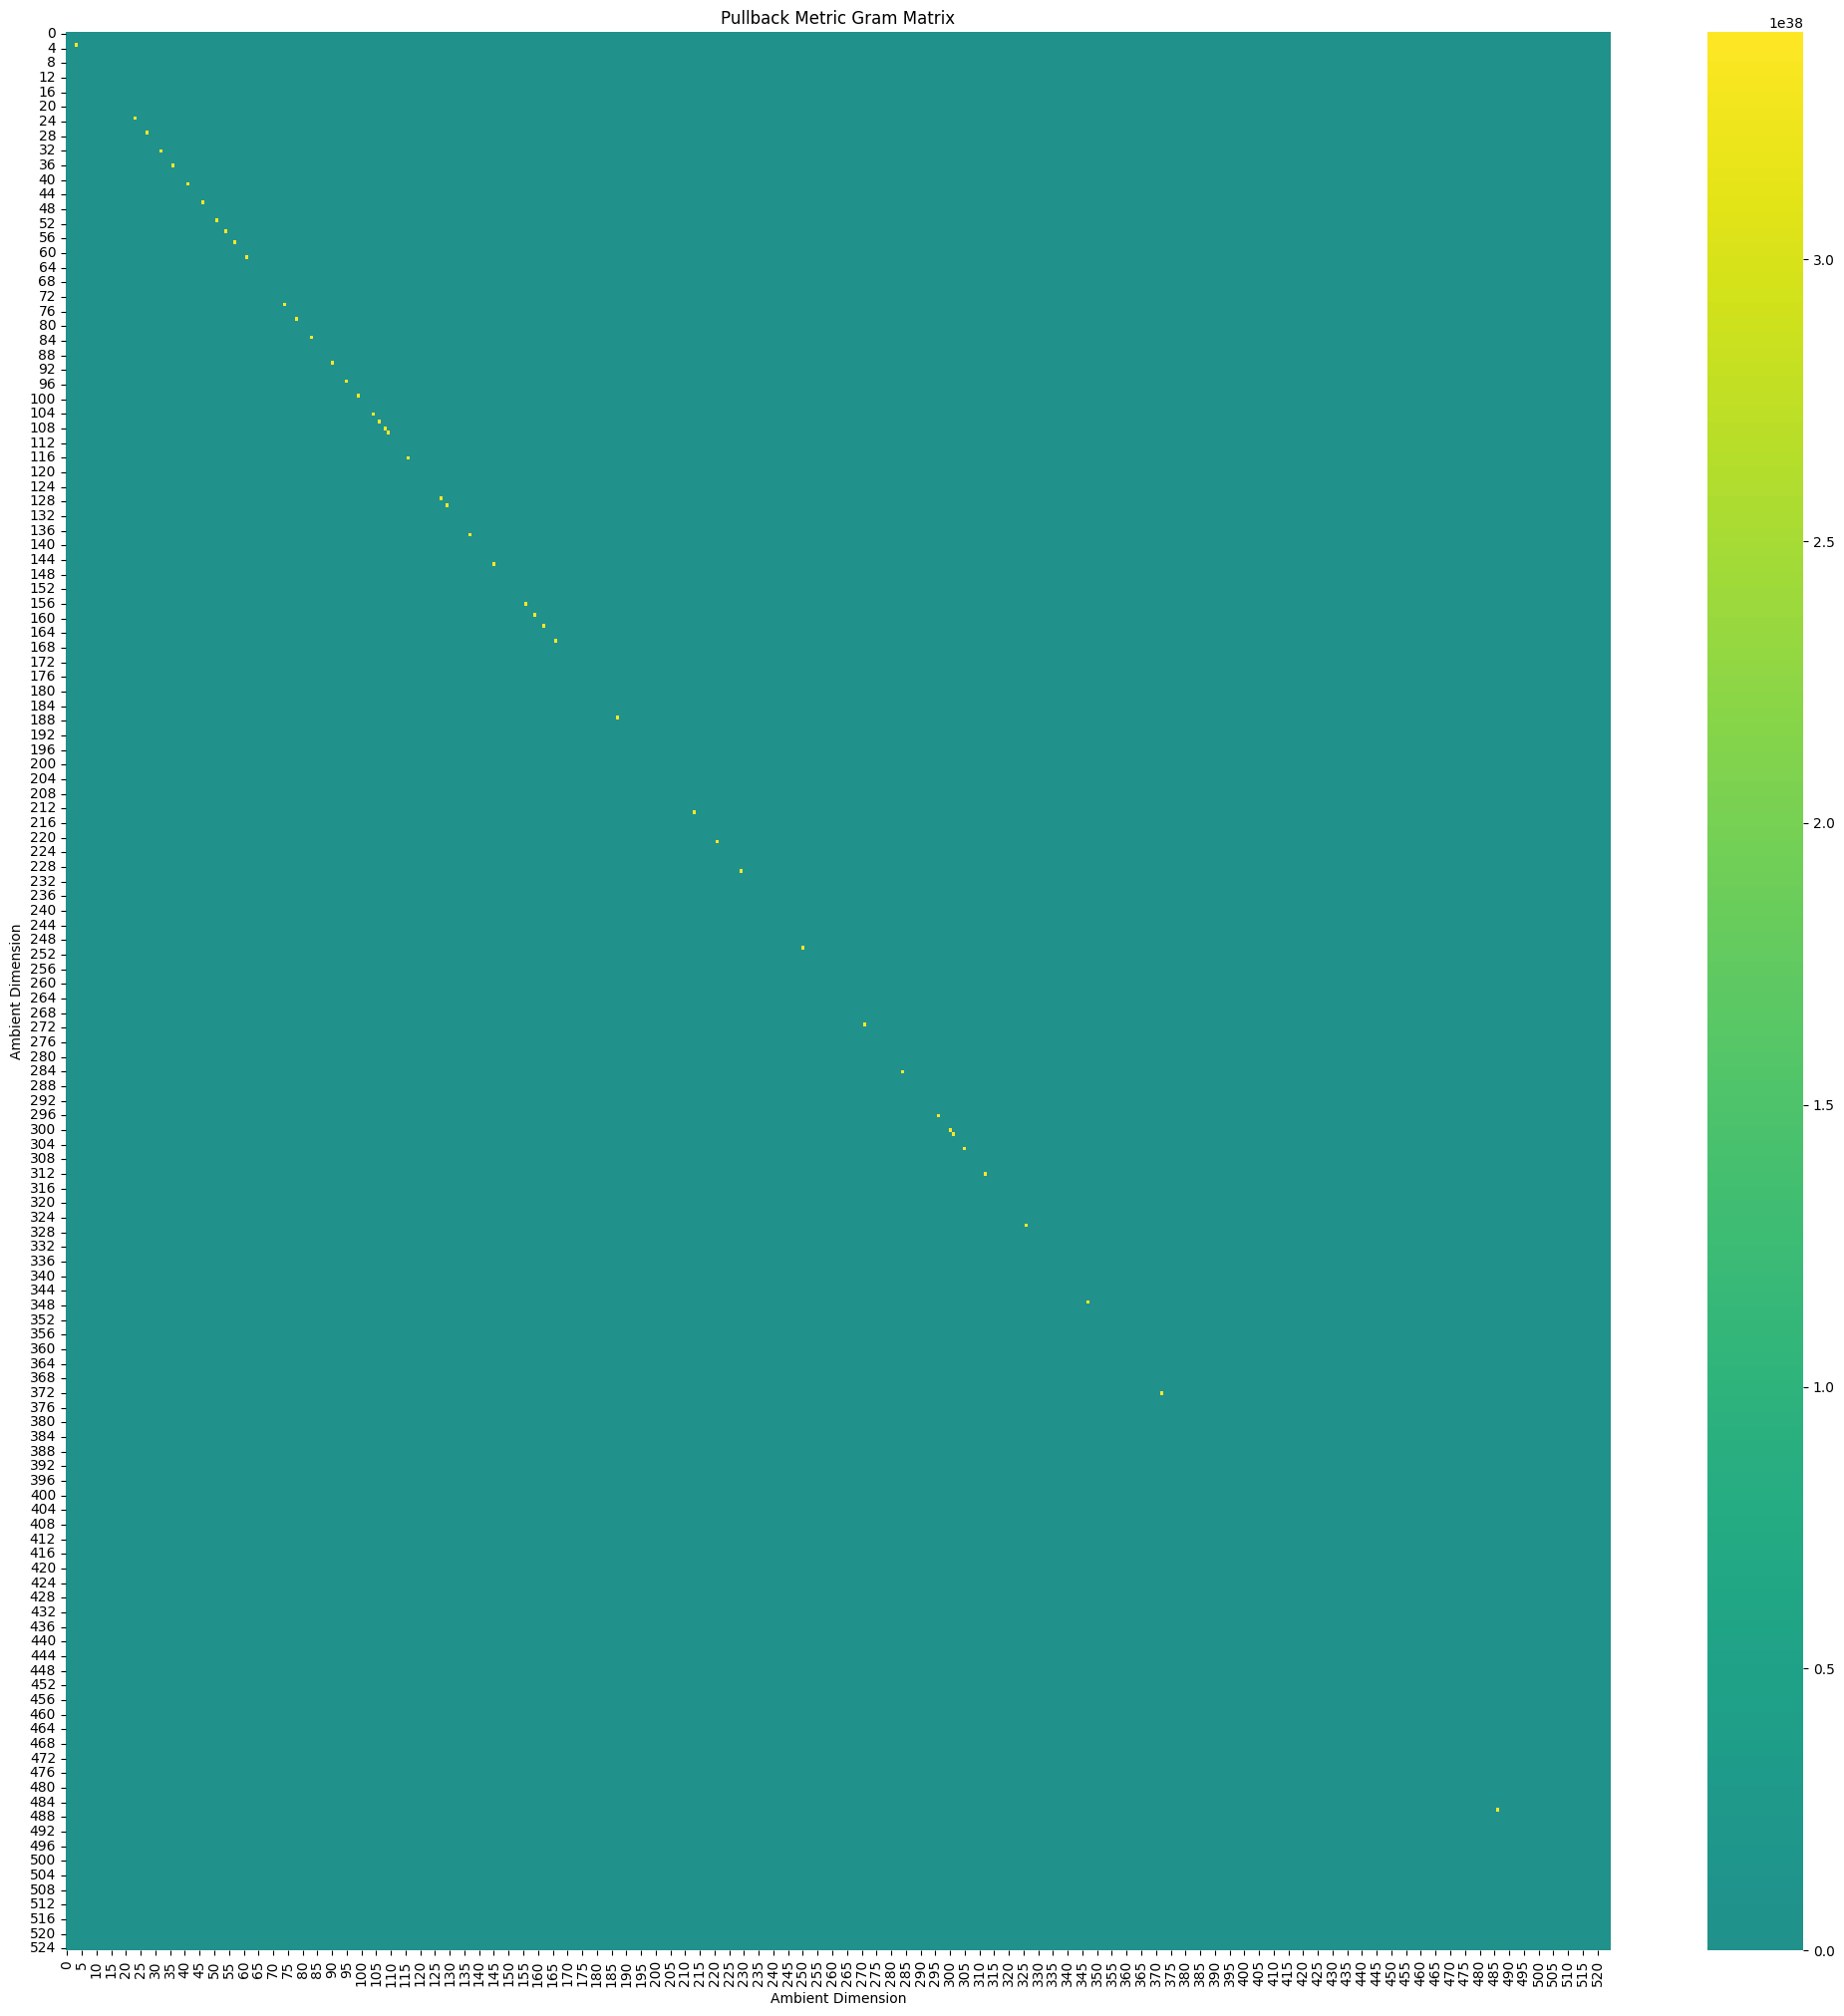

In [17]:
plot_heatmap(
    matrix=np.nan_to_num(agrammtx[0].cpu().numpy(), nan=0.0),
    title="Pullback Metric Gram Matrix",
    xlabel="Ambient Dimension",
    ylabel="Ambient Dimension",
    figsize=(25, 25),
)
plot_heatmap(
    matrix=np.nan_to_num(agrammtxnrm_l[0].cpu().numpy(), nan=0.0),
    title="Pullback Metric Gram Matrix",
    xlabel="Ambient Dimension",
    ylabel="Ambient Dimension",
    figsize=(25, 25),
)

In [18]:
agrammtx[0].cpu().numpy().shape

(525, 525)

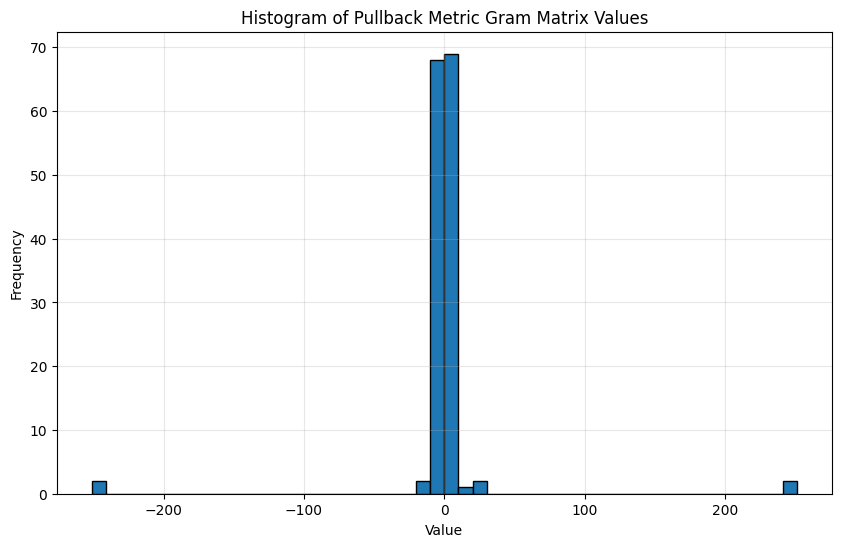

In [19]:
import matplotlib.pyplot as plt

# Flatten the gram matrix and plot histogram
values = agrammtx[0].flatten().cpu().numpy()
values = values[np.abs(values) >= 0.1]
plt.figure(figsize=(10, 6))
plt.hist(values, bins=50, edgecolor="black")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Pullback Metric Gram Matrix Values")
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
torch.nn.functional.softmax((-(agrammtx[0] + agrammtx[0].T)).flatten()).reshape(
    agrammtx[0].shape[0], agrammtx[0].shape[1]
).cpu().numpy().sum()

/tmp/ipykernel_3469/771222681.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  torch.nn.functional.softmax((-(agrammtx[0] + agrammtx[0].T)).flatten()).reshape(


np.float32(1.0)

/tmp/ipykernel_3469/1616287369.py:11: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  torch.nn.functional.softmax((-(agrammtx[0] + agrammtx[0].T)).flatten())


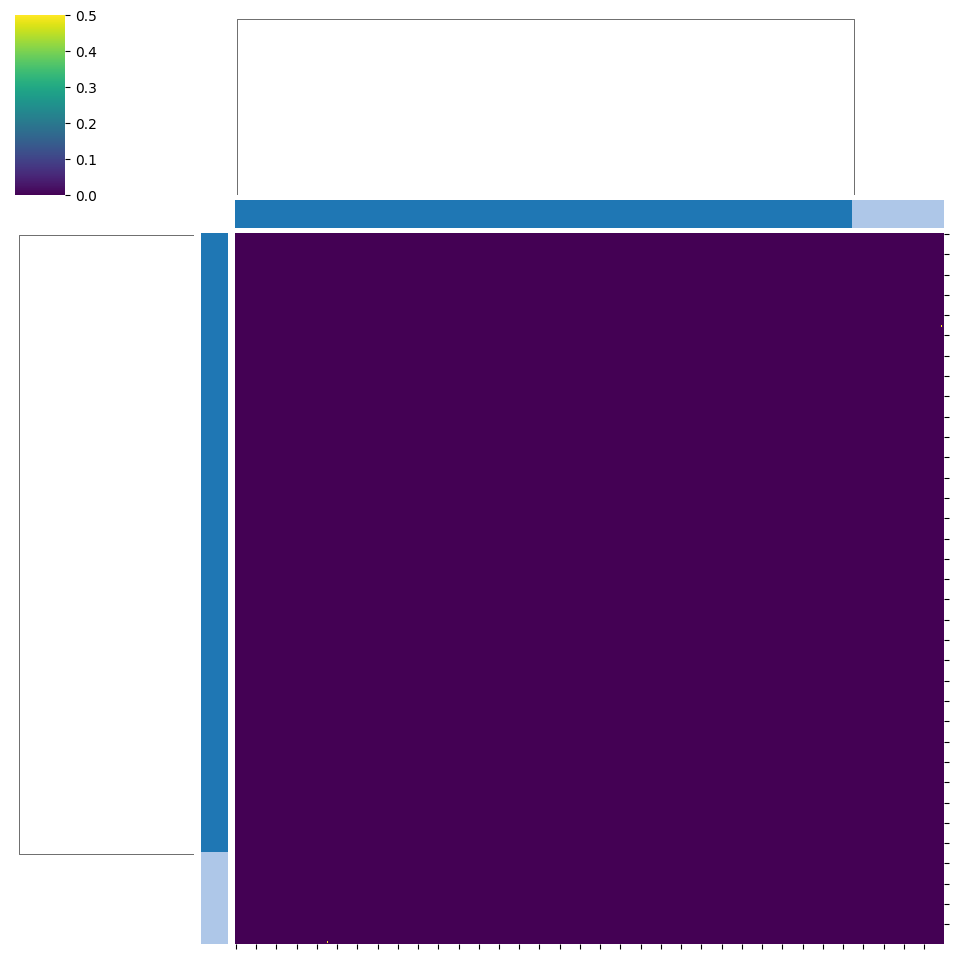

In [21]:
# TODO @pszmk : clustermap of dimensions and mutations
from utils.plotting.clustering import (
    hierarchical_cluster,
    get_clusters_at_levels,
    plot_clustermap,
)
import numpy as np

# 1. Start with a distance matrix D (M x M symmetric matrix)
D = (
    torch.nn.functional.softmax((-(agrammtx[0] + agrammtx[0].T)).flatten())
    .reshape(agrammtx[0].shape[0], agrammtx[0].shape[1])
    .cpu()
    .numpy()
)  # shape: (M, M)

# 2. Perform hierarchical clustering to get linkage matrix
Z = hierarchical_cluster(D, method="average")  # or "ward", "complete", "single"

# 3. Get cluster assignments at a specific level (e.g., 5 clusters)
clusters = get_clusters_at_levels(Z, levels=[5])[5]

# # 4. Plot the clustermap
g = plot_clustermap(
    D=D, Z=Z, clusters=clusters, figsize=(10, 10)  # optional, defaults to (10, 10)
)

In [22]:
# TODO @pszmk : plot just the mutation matrix for a given dimension in the latent from svd -> look what is shown - what are the correlations?

from functools import partial
from pep_compass.models.encoder_decoder.utils import decoder_jacobian_approx

dec_jac_wrpd = partial(
    decoder_jacobian_approx,
    decoder_forward=hydramp.decoder_forward,
    jacobian_eps=0.05,
)

seq_tensor = hydramp.encode_peptides([seq])

jac = dec_jac_wrpd(x=seq_tensor)  # shape: (B, S*V, Z)
# --- SVD ---
U, S, Vh = torch.linalg.svd(jac, full_matrices=False)

In [23]:
U.shape, U[0, :, 0].reshape(25, 21).shape

(torch.Size([1, 525, 64]), torch.Size([25, 21]))

In [24]:
ALPHABET = list(" ACDEFGHIKLMNPQRSTVWY")

In [25]:
# TODO @pszmk :is there a bug in the mutand since we have deacreasing value for the other aa in the sequence

dir: 0


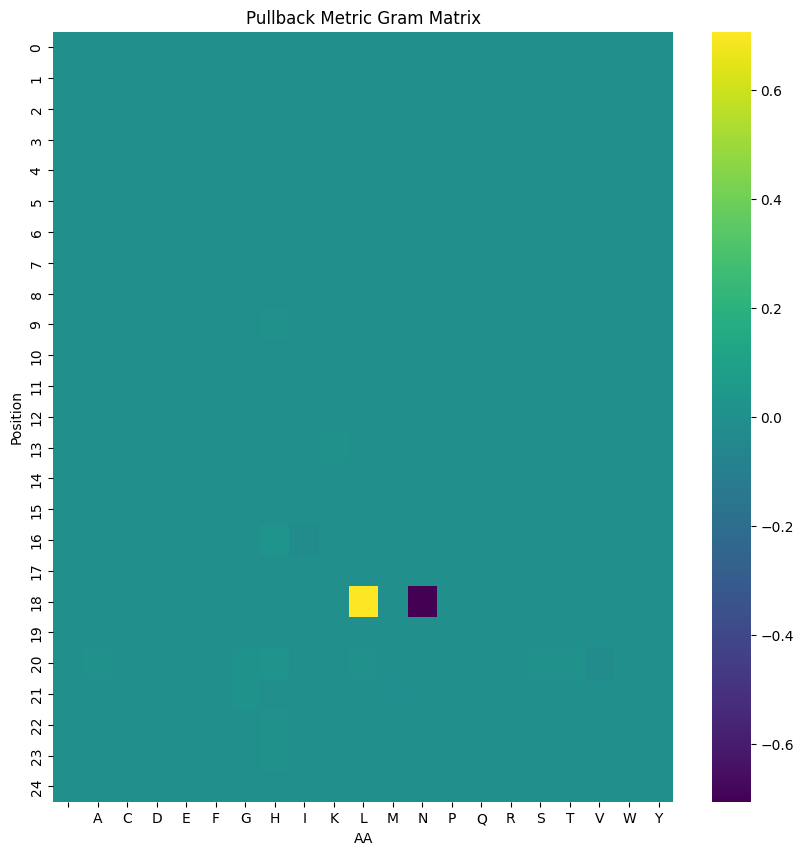

pos: 18
parent AA: L
mutated AA: N
dir: 1


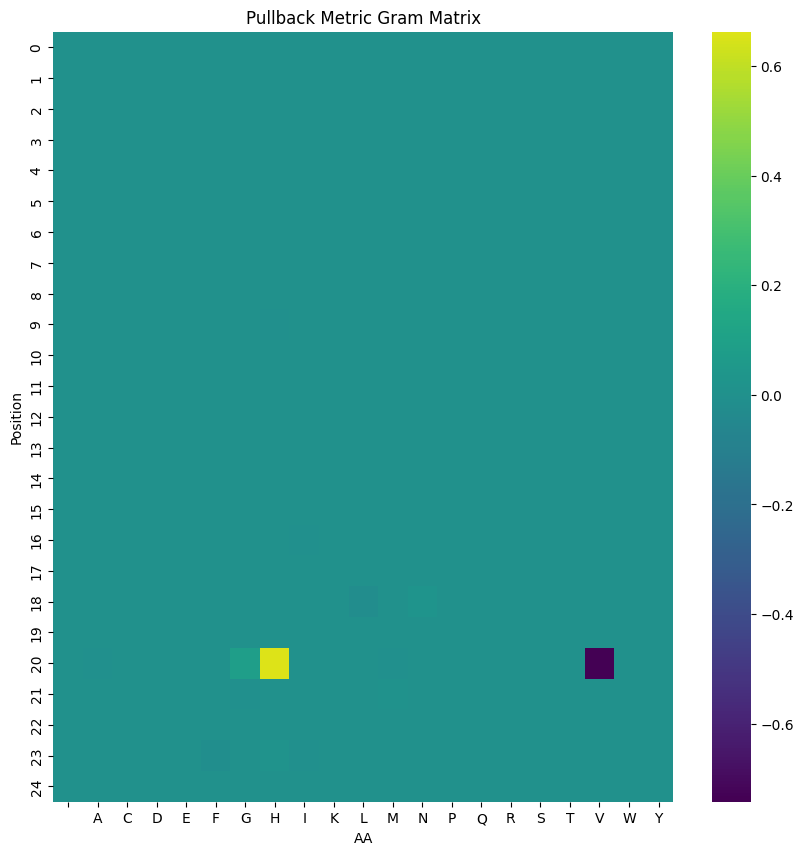

pos: 20
parent AA: H
mutated AA: H
dir: 2


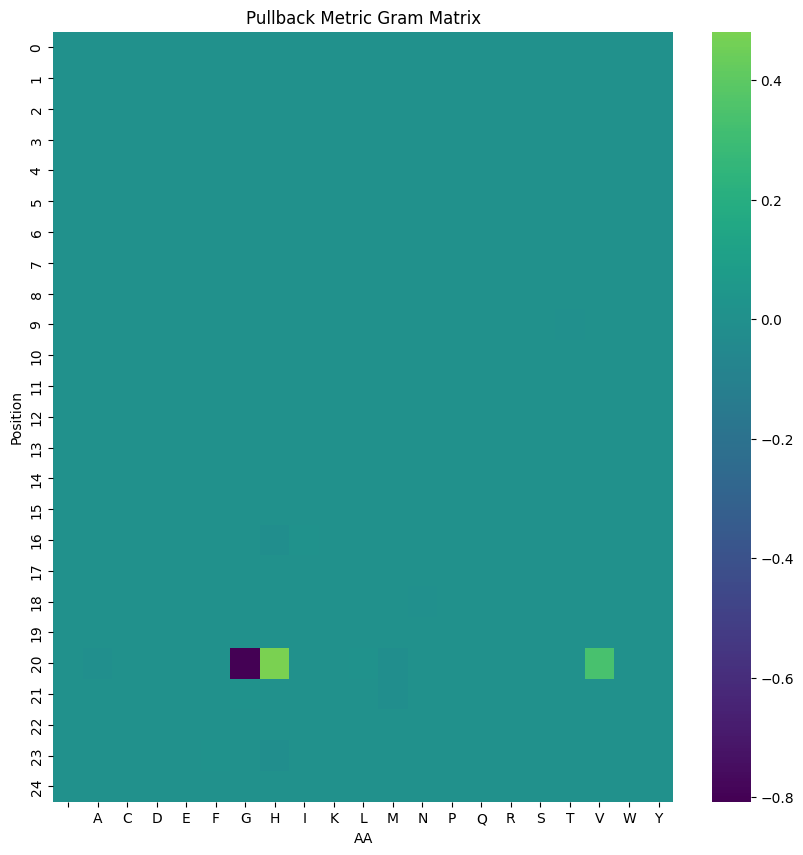

pos: 20
parent AA: H
mutated AA: H
dir: 3


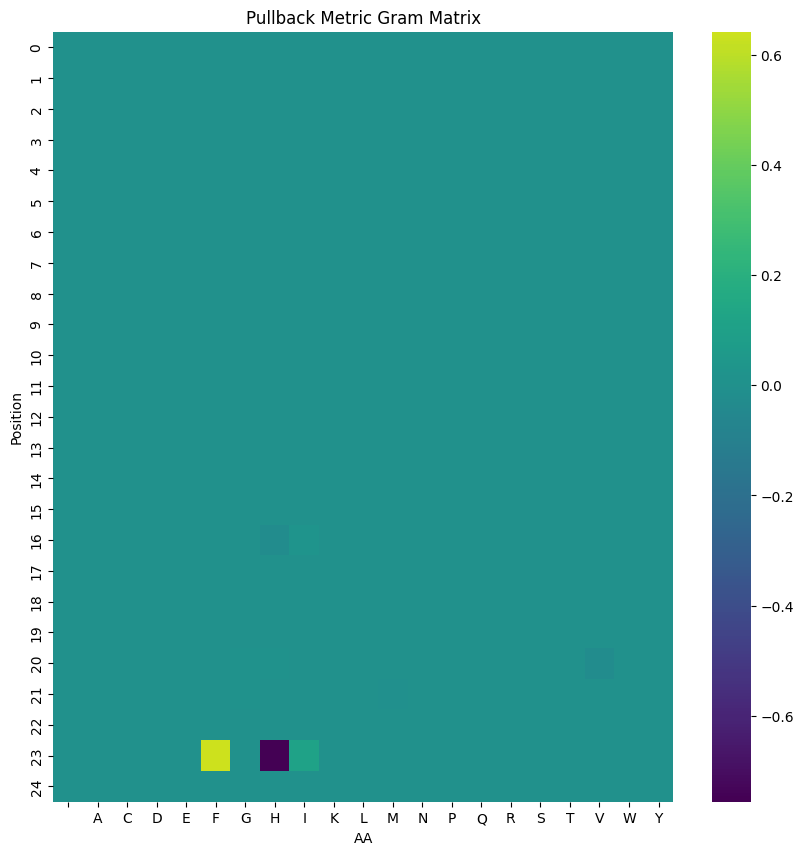

pos: 23
parent AA: H
mutated AA: H
dir: 4


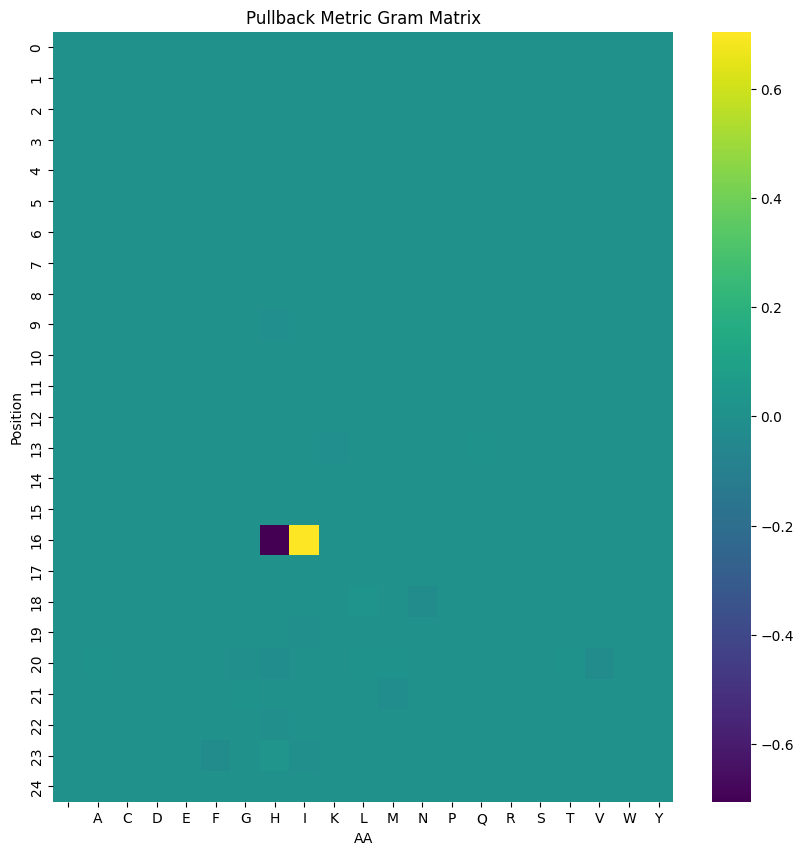

pos: 16
parent AA: H
mutated AA: H
dir: 5


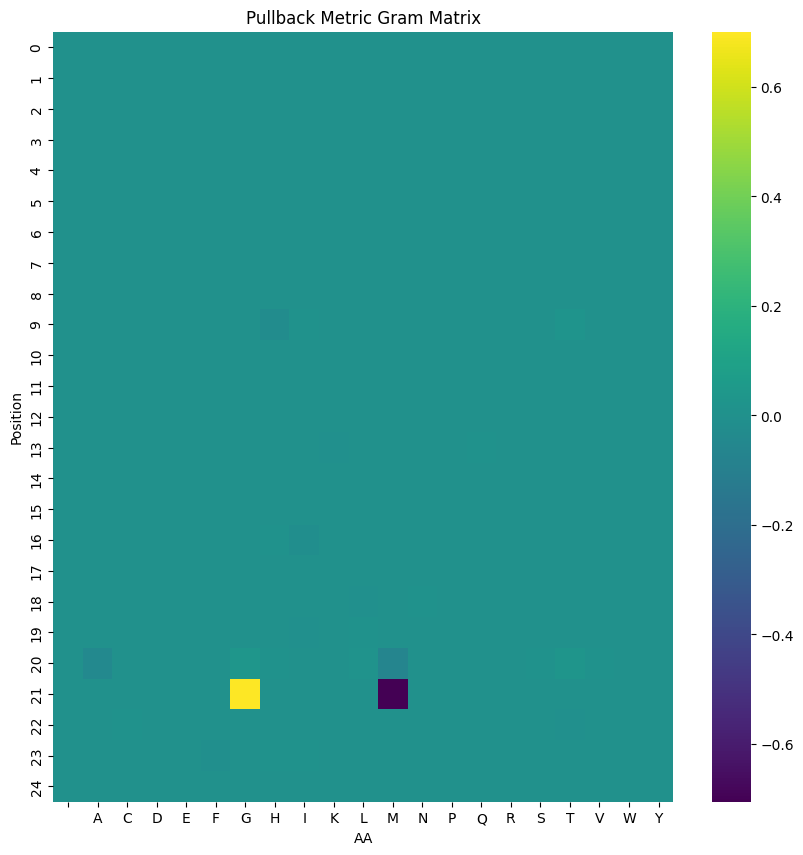

pos: 21
parent AA: G
mutated AA: G
dir: 6


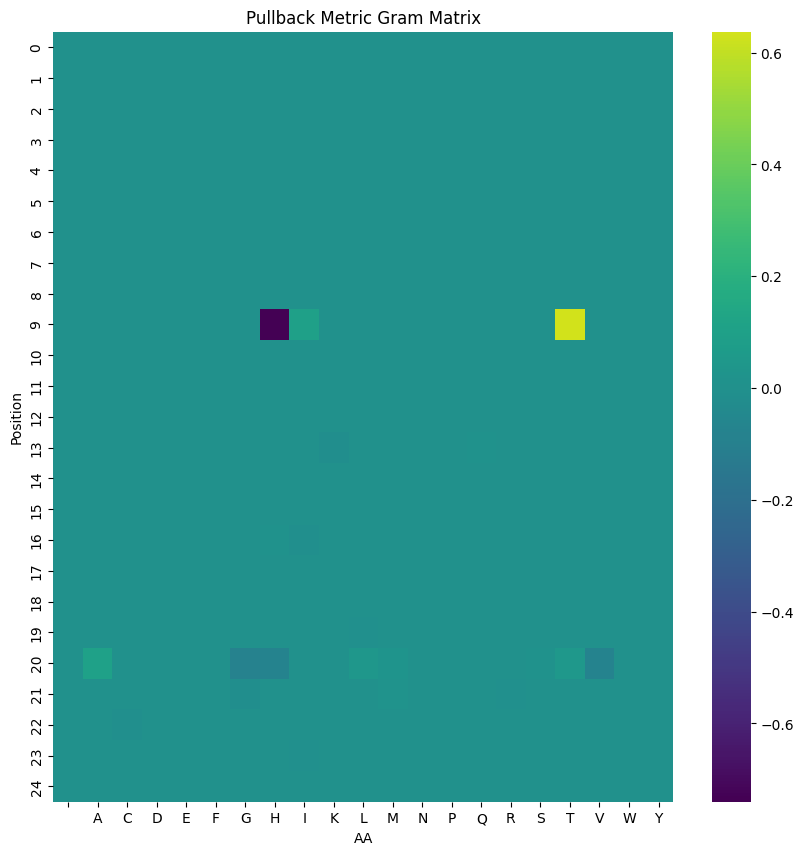

pos: 9
parent AA: H
mutated AA: H
dir: 7


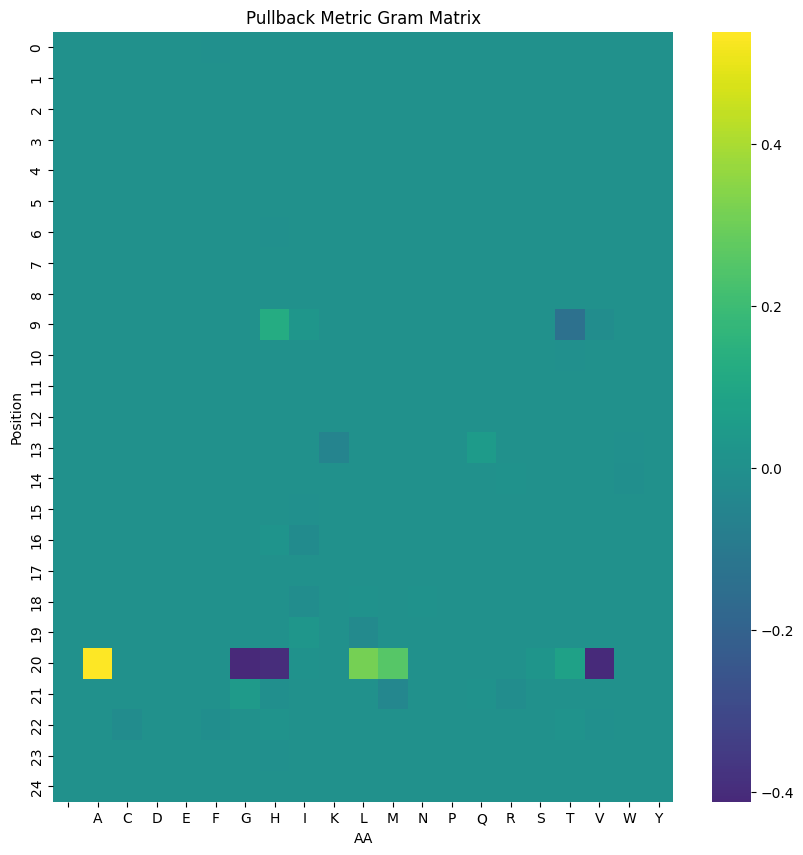

pos: 20
parent AA: H
mutated AA: H
dir: 8


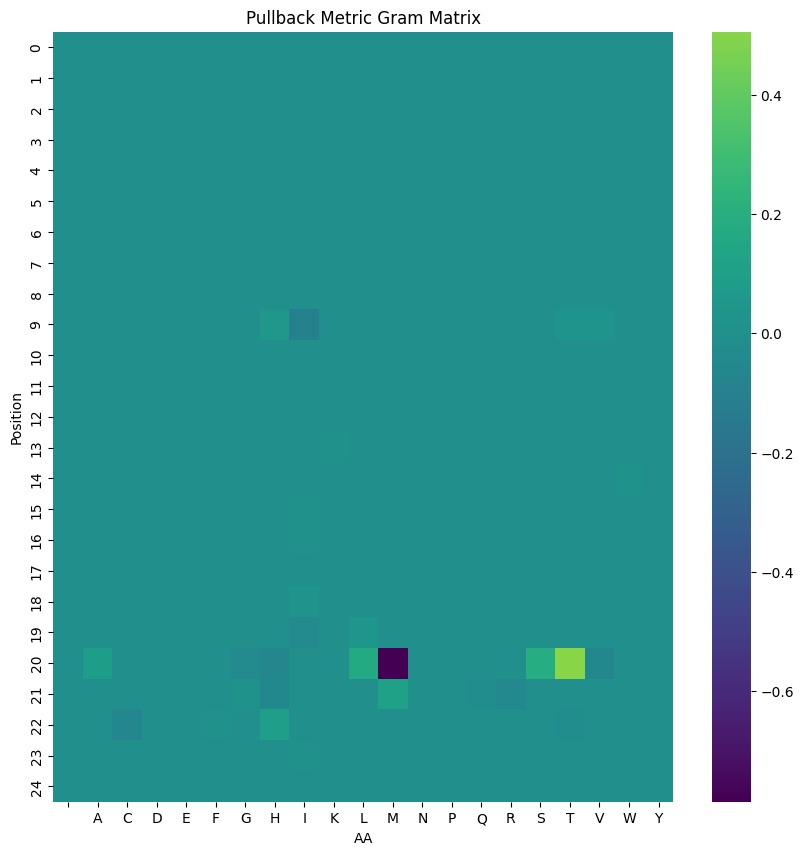

pos: 20
parent AA: H
mutated AA: H
dir: 9


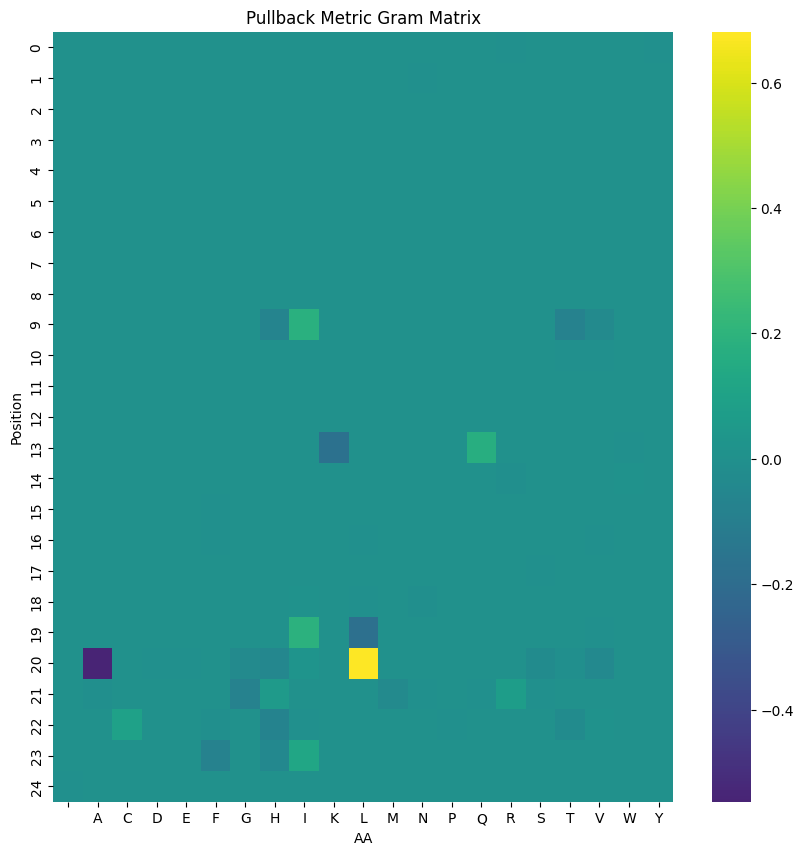

pos: 20
parent AA: H
mutated AA: H


In [26]:
for dir in range(10):
    print(f"dir: {dir}")
    plot_heatmap(
        matrix=U[0, :, dir].reshape(25, 21).cpu().numpy(),
        title="",
        xlabel="AA",
        ylabel="Position",
        figsize=(10, 10),
        xticklabels=ALPHABET,
        # yticklabels=hydramp.vocab,
    )
    pos = U[0, :, dir].reshape(25, 21).abs().sum(dim=1).argmax(dim=0).item()
    print(f"pos: {pos}")
    print(f"parent AA: {seq[pos]}")
    print(f"mutated AA: {mutatnt[pos]}")

In [27]:
seq[18]

'L'

In [28]:
print(seq)
print("FLGLLFHGVHHVGKWIHGNIHGHH")

FLGLLFHGVHHVGKWIHGLIHGHH
FLGLLFHGVHHVGKWIHGNIHGHH


In [29]:
# TODO @pszmk : perform denoising with svd?

In [30]:
# TODO @pszmk : get samples from several peptides

---